# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.5.1
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file
DATA_DIR = '.'   # folder containing the 12 monthly parquet files

sample_file = os.path.join(DATA_DIR, 'yellow_tripdata_2025-01.parquet')
df_test = pd.read_parquet(sample_file)
df_test.info()
print("\nRows in a single month's file:", len(df_test))


<class 'pandas.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommended to not load all the files at once to avoid memory overload.
# A single month already has 3-4 million rows; 12 months combined would be 35-45
# million rows, which is far more than we need (and more than a laptop can
# comfortably hold in memory) for an exploratory analysis. We therefore sample
# each file on disk, one month at a time, and only keep the small sampled
# result in memory.


In [6]:
# Not running on Google Colab here - the parquet files were uploaded directly,
# so there is no need to mount Google Drive.
# from google.colab import drive
# drive.mount('/content/drive')


In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour
#   -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

SAMPLE_FRAC = 0.05          # 5% of every (date, hour) bucket
RANDOM_STATE = 42

file_list = sorted(glob.glob(os.path.join(DATA_DIR, 'yellow_tripdata_2025-*.parquet')))
print(f"Found {len(file_list)} monthly files")

monthly_samples = []

for file_path in file_list:
    file_name = os.path.basename(file_path)
    try:
        # Reading the current file
        month_df = pd.read_parquet(file_path)

        # Derive helper columns used purely for sampling
        month_df['_pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['_pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current month here, by
        # appending the sampled data from each (date, hour) bucket.
        sampled_data = []

        # Loop through every (date, hour) combination present in the month
        for (_, _), hour_data in month_df.groupby(['_pickup_date', '_pickup_hour']):
            # Sample 5% of the hourly data randomly
            sample = hour_data.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
            # add data of this hour to the list
            sampled_data.append(sample)

        # Concatenate the sampled data of all the dates/hours for this month
        month_sampled = pd.concat(sampled_data, ignore_index=True)
        month_sampled.drop(columns=['_pickup_date', '_pickup_hour'], inplace=True)
        monthly_samples.append(month_sampled)

        print(f"{file_name}: {len(month_df):>9,} rows -> sampled {len(month_sampled):>7,} rows")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Combine every month's sampled data into a single dataframe for the year
df = pd.concat(monthly_samples, ignore_index=True)
print("\nFinal combined (sampled) dataset shape:", df.shape)


Found 12 monthly files
yellow_tripdata_2025-01.parquet: 3,475,226 rows -> sampled 173,744 rows
yellow_tripdata_2025-02.parquet: 3,577,543 rows -> sampled 178,880 rows
yellow_tripdata_2025-03.parquet: 4,145,257 rows -> sampled 207,259 rows
yellow_tripdata_2025-04.parquet: 3,970,553 rows -> sampled 198,511 rows
yellow_tripdata_2025-05.parquet: 4,591,845 rows -> sampled 229,591 rows
yellow_tripdata_2025-06.parquet: 4,322,960 rows -> sampled 216,141 rows
yellow_tripdata_2025-07.parquet: 3,898,963 rows -> sampled 194,946 rows
yellow_tripdata_2025-08.parquet: 3,574,091 rows -> sampled 178,696 rows
yellow_tripdata_2025-09.parquet: 4,251,015 rows -> sampled 212,549 rows
yellow_tripdata_2025-10.parquet: 4,428,699 rows -> sampled 221,435 rows
yellow_tripdata_2025-11.parquet: 4,181,444 rows -> sampled 209,070 rows
yellow_tripdata_2025-12.parquet: 4,305,006 rows -> sampled 215,251 rows

Final combined (sampled) dataset shape: (2436073, 20)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet so that later sections can load it directly
# without repeating the (slow) sampling step above.
OUTPUT_PATH = 'nyc_taxi_2025_sampled.parquet'
df.to_parquet(OUTPUT_PATH, index=False)
print("Saved sampled dataset to:", OUTPUT_PATH)


Saved sampled dataset to: nyc_taxi_2025_sampled.parquet


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new (sampled) data file directly, instead of re-sampling from the
# raw monthly files every time we re-run the notebook.
df = pd.read_parquet('nyc_taxi_2025_sampled.parquet')


In [10]:
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2024-12-31 23:51:20,2025-01-01 00:00:00,1.0,12.89,1.0,N,138,40,1,48.50,6.0,0.5,11.55,0.00,1.0,69.30,0.0,1.75,0.0
1,2,2025-01-01 00:36:00,2025-01-01 01:04:56,1.0,3.63,1.0,N,234,143,1,27.50,1.0,0.5,6.50,0.00,1.0,39.00,2.5,0.00,0.0
2,2,2025-01-01 00:14:06,2025-01-01 00:51:56,1.0,16.44,5.0,N,132,113,1,87.00,0.0,0.0,10.00,6.94,1.0,107.44,2.5,0.00,0.0
3,2,2025-01-01 00:23:15,2025-01-01 00:28:01,1.0,0.91,1.0,N,142,239,1,7.20,1.0,0.5,2.44,0.00,1.0,14.64,2.5,0.00,0.0
4,2,2025-01-01 00:55:00,2025-01-01 01:03:32,NaN,1.55,NaN,NaN,40,228,0,-3.28,0.0,0.5,0.00,0.00,1.0,1.11,NaN,NaN,0.0


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2436073 entries, 0 to 2436072
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed

# Reset the index so it is a clean, contiguous RangeIndex after sampling/concatenation
df.reset_index(drop=True, inplace=True)

# 'store_and_fwd_flag' only tells us whether the trip record was cached in the
# vehicle before being sent to the server - it has no bearing on demand, fares,
# routing or customer experience, so we drop it for this analysis.
cols_to_drop = [c for c in ['store_and_fwd_flag'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("Columns after cleanup:", df.columns.tolist())
df.shape


Columns after cleanup: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


(2436073, 19)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# Combine the two airport fee columns
# Depending on the exact TLC file version, the airport fee sometimes appears
# twice under slightly different names/casing (e.g. 'Airport_fee' and
# 'airport_fee'). We detect any such duplicates and combine them into a single
# lower-case 'airport_fee' column.
airport_cols = [c for c in df.columns if c.lower() == 'airport_fee']
print("Airport-fee related columns found:", airport_cols)

if len(airport_cols) > 1:
    # Combine by taking the max of the (mostly-zero) values row-wise, since a
    # trip can only genuinely have one airport fee charged.
    df['airport_fee'] = df[airport_cols].max(axis=1)
    extra_cols = [c for c in airport_cols if c != 'airport_fee']
    df.drop(columns=extra_cols, inplace=True)
elif len(airport_cols) == 1 and airport_cols[0] != 'airport_fee':
    df.rename(columns={airport_cols[0]: 'airport_fee'}, inplace=True)

print("Columns after combining airport fee:", [c for c in df.columns if 'airport' in c.lower()])


Airport-fee related columns found: ['Airport_fee']
Columns after combining airport fee: ['airport_fee']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [14]:
# check where values of fare amount are negative
neg_fare = df[df['fare_amount'] < 0]
print("Number of trips with negative fare_amount:", len(neg_fare))
neg_fare.head()


Number of trips with negative fare_amount: 140964


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee
4,2,2025-01-01 00:55:00,2025-01-01 01:03:32,NaN,1.55,NaN,40,228,0,-3.28,0.0,0.5,0.0,0.0,1.0,1.11,NaN,NaN,0.0
22,2,2025-01-01 00:38:14,2025-01-01 00:51:09,NaN,1.50,NaN,107,211,0,-4.89,0.0,0.5,0.0,0.0,1.0,-0.89,NaN,NaN,0.0
36,2,2025-01-01 00:32:49,2025-01-01 00:39:27,NaN,0.65,NaN,211,144,0,-0.54,0.0,0.5,0.0,0.0,1.0,3.46,NaN,NaN,0.0
74,2,2025-01-01 00:54:48,2025-01-01 01:29:42,NaN,17.43,NaN,252,261,0,-0.62,0.0,0.5,0.0,0.0,1.0,3.38,NaN,NaN,0.0
96,2,2025-01-01 00:55:01,2025-01-01 01:04:56,NaN,0.67,NaN,170,162,0,-2.82,0.0,0.5,0.0,0.0,1.0,1.18,NaN,NaN,0.0


Did you notice something different in the `RatecodeID` column for above records?

In [15]:
# Analyse RatecodeID for the negative fare amounts
print(neg_fare['RatecodeID'].value_counts(dropna=False))

# Most negative-fare rows carry the same RatecodeID distribution as the rest of
# the data (mostly 1 = Standard rate) but are dominated by payment_type 3/4
# (No charge / Dispute), which strongly suggests these are refunded/voided or
# reversed trips that were logged with a negative sign rather than being
# removed from the system - i.e. a data-entry convention, not "real" negative
# fares.
print(neg_fare['payment_type'].value_counts(dropna=False))


RatecodeID
NaN    100836
1.0     35228
2.0      2620
5.0      1122
3.0       819
4.0       339
Name: count, dtype: int64
payment_type
0    100836
4     25638
2      9367
3      5066
1        57
Name: count, dtype: int64


In [16]:
# Find which columns have negative values
monetary_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                  'improvement_surcharge', 'total_amount', 'congestion_surcharge',
                  'airport_fee']
monetary_cols = [c for c in monetary_cols if c in df.columns]

neg_counts = (df[monetary_cols] < 0).sum()
print("Count of negative values per monetary column:")
print(neg_counts[neg_counts > 0])


Count of negative values per monetary column:
fare_amount              140964
extra                     20679
mta_tax                   38202
tip_amount                   87
tolls_amount               3685
improvement_surcharge     40276
total_amount              48690
congestion_surcharge      31931
airport_fee                8350
dtype: int64


In [17]:
# fix these negative values
# Since negative values in these monetary columns are essentially the same
# trips recorded with a flipped sign (refunds/voided/disputed trips as seen
# above), we convert them to their absolute value rather than dropping the
# rows outright - this preserves the trip record while correcting the sign
# error.
for col in monetary_cols:
    df[col] = df[col].abs()

# Confirm no negative values remain
print((df[monetary_cols] < 0).sum())


fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [18]:
# Find the proportion of missing values in each column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Percentage of missing values per column:")
print(missing_pct)


Percentage of missing values per column:
congestion_surcharge    23.407755
RatecodeID              23.407755
passenger_count         23.407755
airport_fee             23.407755
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [19]:
# Display the rows with null values in passenger_count
df[df['passenger_count'].isnull()].head()

# Impute NaN values in 'passenger_count' with the mode (the most common
# passenger count, which for taxi trips is almost always 1)
mode_passenger = df['passenger_count'].mode()[0]
print("Mode passenger_count:", mode_passenger)
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger)

# Check for zeroes in passenger_count - a trip cannot legitimately have 0
# passengers, so we treat 0 the same way as a missing value and impute it too.
print("Zero passenger_count rows:", (df['passenger_count'] == 0).sum())
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mode_passenger

df['passenger_count'] = df['passenger_count'].astype(int)
df['passenger_count'].value_counts().sort_index()


Mode passenger_count: 1.0
Zero passenger_count rows: 13314


passenger_count
1    2063002
2     256774
3      60174
4      41815
5       9090
6       5206
7          2
8          9
9          1
Name: count, dtype: int64

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [20]:
# Fix missing values in 'RatecodeID'
print("Missing RatecodeID:", df['RatecodeID'].isnull().sum())
mode_ratecode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecode).astype(int)
print("RatecodeID value counts after imputation:")
print(df['RatecodeID'].value_counts())


Missing RatecodeID: 570230


RatecodeID value counts after imputation:
RatecodeID
1     2296116
2       65102
99      39442
5       22216
3        7477
4        5719
6           1
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [21]:
# handle null values in congestion_surcharge
print("Missing congestion_surcharge:", df['congestion_surcharge'].isnull().sum())

# A missing congestion surcharge most likely means no congestion surcharge was
# applied to that trip (e.g. trips outside Manhattan's congestion zone), so we
# impute with 0 rather than a measure of central tendency.
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)


Missing congestion_surcharge: 570230


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [22]:
# Handle any remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("Columns still containing missing values:")
print(remaining_missing)

# Any remaining monetary columns (e.g. airport_fee) with missing values most
# likely mean the fee did not apply - impute with 0.
for col in remaining_missing.index:
    if col in monetary_cols:
        df[col] = df[col].fillna(0)

# If tpep_dropoff_datetime or any location column is missing, that trip record
# is unusable for analysis, so we drop those rows (should be very rare).
critical_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID']
df.dropna(subset=[c for c in critical_cols if c in df.columns], inplace=True)

print("\nMissing values after final cleanup:")
print(df.isnull().sum().sum())


Columns still containing missing values:
airport_fee    570230
dtype: int64

Missing values after final cleanup:
0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [23]:
# Describe the data and check if there are any potential outliers present
df.describe()

# A few things stand out from the summary statistics above:
# - trip_distance has a max value in the hundreds of miles, which is
#   implausible for a single NYC taxi trip.
# - fare_amount / total_amount have very large maximums relative to their
#   75th percentile, hinting at a handful of extreme fares.
# - passenger_count has a max well above the vehicle capacity (should be capped
#   around 4-6 for a standard yellow cab).
# - payment_type includes a value of 0, which is not defined in the data
#   dictionary (valid values are 1-6).
print("Max trip_distance:", df['trip_distance'].max())
print("Max fare_amount:", df['fare_amount'].max())
print("Max passenger_count:", df['passenger_count'].max())
print("payment_type value counts:\n", df['payment_type'].value_counts())


Max trip_distance: 254846.53
Max fare_amount: 1807.6
Max passenger_count: 9
payment_type value counts:
 payment_type
1    1562233
0     570230
2     233823
4      54183
3      15604
Name: count, dtype: int64


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [24]:
# remove passenger_count > 6
print("Rows with passenger_count > 6:", (df['passenger_count'] > 6).sum())
df = df[df['passenger_count'] <= 6].copy()
df.shape


Rows with passenger_count > 6: 12


(2436061, 19)

In [25]:
# Continue with outlier handling

before = len(df)

# 1) trip_distance is nearly 0 but fare_amount is unusually high (> $300):
#    almost certainly a meter/registration error - drop these rows.
mask_1 = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print("Near-zero distance but fare > $300:", mask_1.sum())

# 2) trip_distance AND fare_amount are both 0 but pickup/dropoff zones differ:
#    a real trip between two different zones cannot have zero distance and
#    zero fare, so these are data errors - drop them.
mask_2 = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
print("Zero distance & zero fare but different zones:", mask_2.sum())

# 3) trip_distance > 250 miles: far beyond any realistic trip within/around NYC.
mask_3 = df['trip_distance'] > 250
print("trip_distance > 250 miles:", mask_3.sum())

# 4) payment_type == 0: not a defined value in the data dictionary.
mask_4 = df['payment_type'] == 0
print("payment_type == 0:", mask_4.sum())

df = df[~(mask_1 | mask_2 | mask_3 | mask_4)].copy()

print(f"\nRows removed as outliers/errors: {before - len(df)}")
print("Remaining rows:", len(df))


Near-zero distance but fare > $300: 115
Zero distance & zero fare but different zones: 76
trip_distance > 250 miles: 97
payment_type == 0: 570230

Rows removed as outliers/errors: 570434
Remaining rows: 1865627


In [26]:
# Do any columns need standardising?

# Standardise categorical/coded columns to integer dtype for consistency
for col in ['VendorID', 'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Create a trip_duration column (minutes) - used repeatedly throughout the EDA
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Drop trips with non-positive or absurdly long durations (data errors)
before = len(df)
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 180)].copy()
print("Rows removed due to invalid trip_duration:", before - len(df))

# Add convenient time-based helper columns used throughout the EDA
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
df['pickup_month_num'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek >= 5

df.reset_index(drop=True, inplace=True)
df.shape


Rows removed due to invalid trip_duration: 28558


(1837069, 25)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [27]:
df.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'cbd_congestion_fee',
 'trip_duration',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_num',
 'is_weekend']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical (nominal - a code identifying the vendor)
* `tpep_pickup_datetime`: Datetime (can be decomposed into numerical/categorical temporal features)
* `tpep_dropoff_datetime`: Datetime (can be decomposed into numerical/categorical temporal features)
* `passenger_count`: Numerical (discrete)
* `trip_distance`: Numerical (continuous)
* `RatecodeID`: Categorical (nominal - a code for the rate type)
* `PULocationID`: Categorical (nominal - a zone identifier)
* `DOLocationID`: Categorical (nominal - a zone identifier)
* `payment_type`: Categorical (nominal - a code for how the trip was paid)
* `pickup_hour`: Categorical/ordinal (derived from datetime; also usable as a numeric cyclical feature)
* `trip_duration`: Numerical (continuous)


The following monetary parameters belong in the same category, is it categorical or numerical?
All of these are **Numerical (continuous)** variables, since they represent measured dollar amounts rather than labels/categories:

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

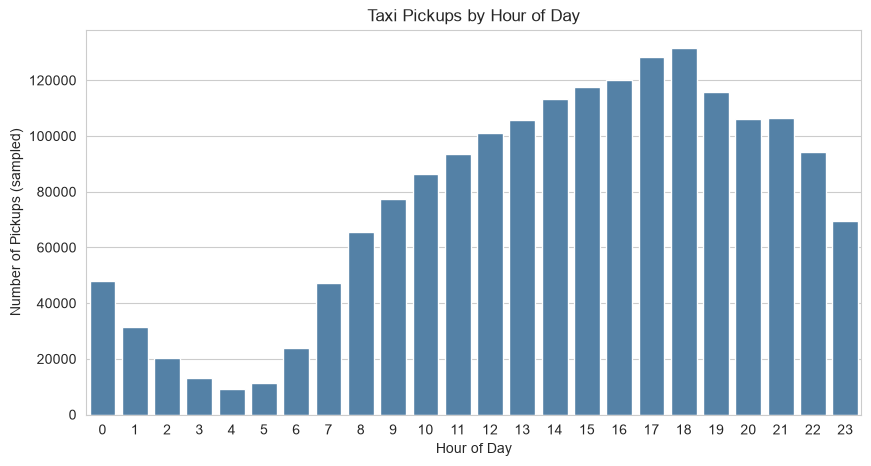

In [28]:
# Find and show the hourly trends in taxi pickups
hourly_counts = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='steelblue')
plt.title('Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups (sampled)')
plt.show()


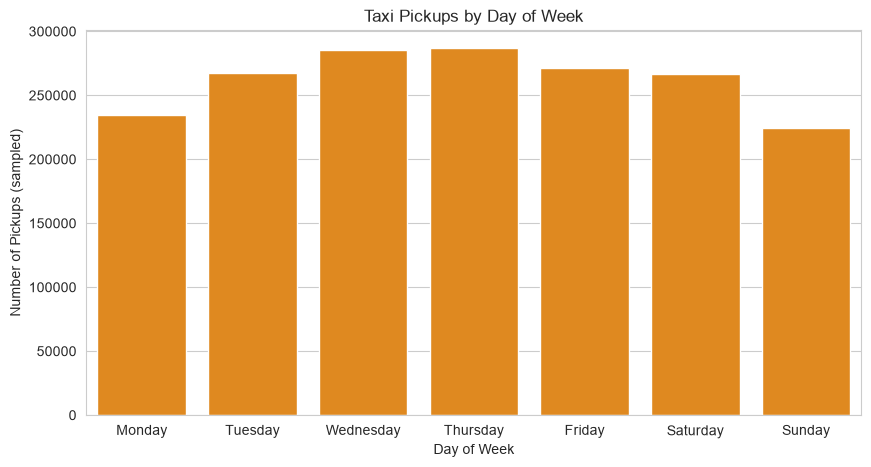

In [29]:
# Find and show the daily trends in taxi pickups (days of the week)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_counts = df['pickup_day'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_counts.index, y=daily_counts.values, color='darkorange')
plt.title('Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups (sampled)')
plt.show()


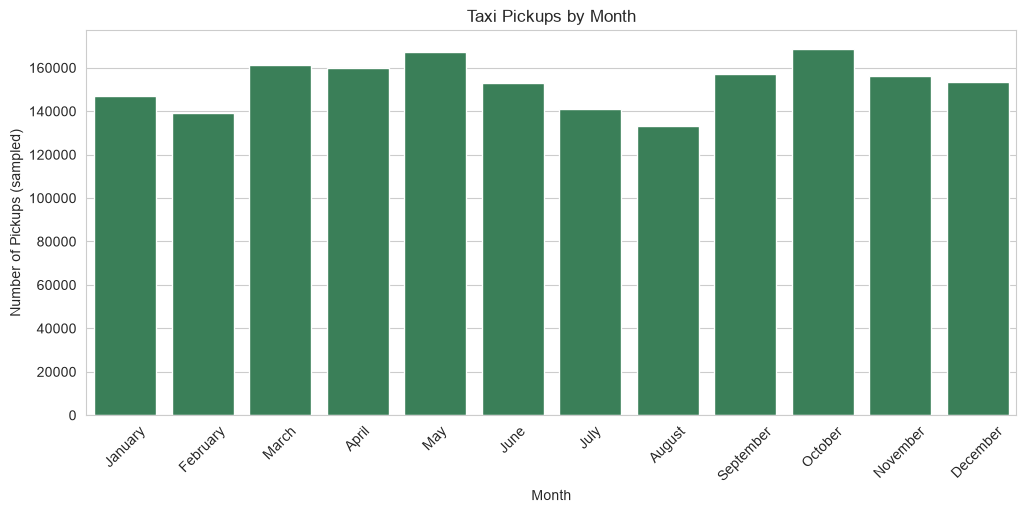

In [30]:
# Show the monthly trends in pickups
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_counts = df['pickup_month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, color='seagreen')
plt.title('Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Pickups (sampled)')
plt.xticks(rotation=45)
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [31]:
# Analyse the above parameters
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    n_zero = (df[col] == 0).sum()
    n_neg = (df[col] < 0).sum()
    print(f"{col:15s} -> zeros: {n_zero:>7,} ({n_zero/len(df)*100:5.2f}%)   negatives: {n_neg}")


fare_amount     -> zeros:     788 ( 0.04%)   negatives: 0
tip_amount      -> zeros: 411,781 (22.42%)   negatives: 0
total_amount    -> zeros:     232 ( 0.01%)   negatives: 0
trip_distance   -> zeros:  23,761 ( 1.29%)   negatives: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [32]:
# Create a df with non zero entries for the selected parameters.
# Note: trip_distance == 0 can genuinely happen when pickup and dropoff are in
# the same zone (e.g. a very short trip or a cancelled-meter trip that still
# got charged), so we don't blanket-drop those - we only exclude zero-fare /
# zero-total trips, which are not meaningful for revenue or fare analysis.
df_nonzero = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)].copy()
print("Rows in df_nonzero:", len(df_nonzero), "out of", len(df))


Rows in df_nonzero: 1836281 out of 1837069


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

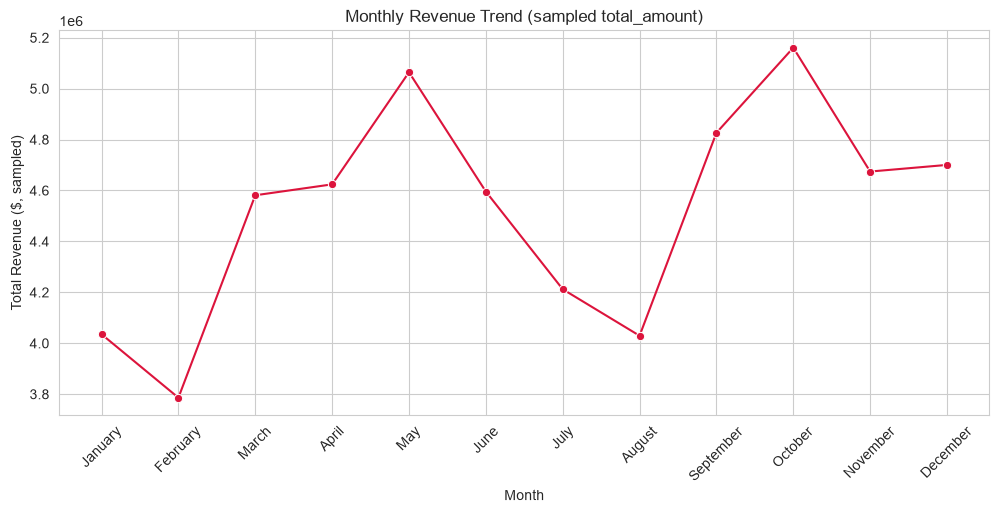

January      4035300.95
February     3786153.39
March        4581143.41
April        4623993.16
May          5064298.74
June         4595730.95
July         4212165.58
August       4029512.30
September    4826446.43
October      5160667.30
November     4674292.13
December     4700339.89
Name: total_amount, dtype: float64

In [33]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_nonzero.groupby('pickup_month_num')['total_amount'].sum().reindex(range(1, 13))
monthly_revenue.index = month_order

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', color='crimson')
plt.title('Monthly Revenue Trend (sampled total_amount)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($, sampled)')
plt.xticks(rotation=45)
plt.show()

monthly_revenue


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

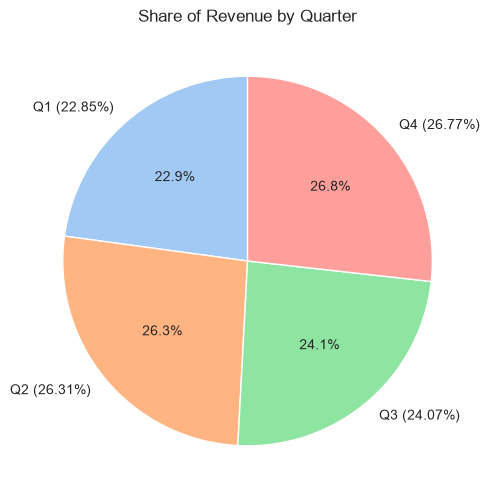

quarter
1    22.85
2    26.31
3    24.07
4    26.77
Name: total_amount, dtype: float64

In [34]:
# Calculate proportion of each quarter
df_nonzero['quarter'] = ((df_nonzero['pickup_month_num'] - 1) // 3) + 1
quarterly_revenue = df_nonzero.groupby('quarter')['total_amount'].sum()
quarterly_share = (quarterly_revenue / quarterly_revenue.sum() * 100).round(2)

plt.figure(figsize=(6, 6))
plt.pie(quarterly_share, labels=[f"Q{q} ({v}%)" for q, v in quarterly_share.items()],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Share of Revenue by Quarter')
plt.show()

quarterly_share


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

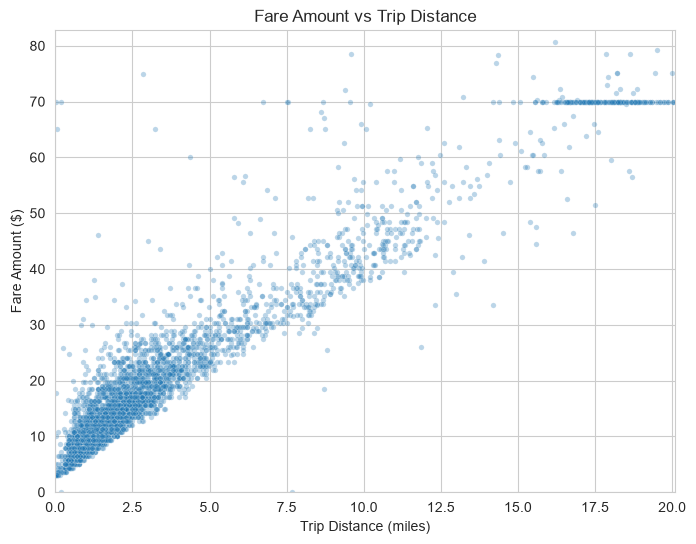

Correlation between trip_distance and fare_amount: 0.925


In [35]:
# Show how trip fare is affected by distance
dist_fare = df_nonzero[df_nonzero['trip_distance'] > 0]

plt.figure(figsize=(8, 6))
sample_plot = dist_fare.sample(n=min(5000, len(dist_fare)), random_state=42)
sns.scatterplot(data=sample_plot, x='trip_distance', y='fare_amount', alpha=0.3, s=15)
plt.xlim(0, dist_fare['trip_distance'].quantile(0.99))
plt.ylim(0, dist_fare['fare_amount'].quantile(0.99))
plt.title('Fare Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()

corr = dist_fare['trip_distance'].corr(dist_fare['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {corr:.3f}")



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

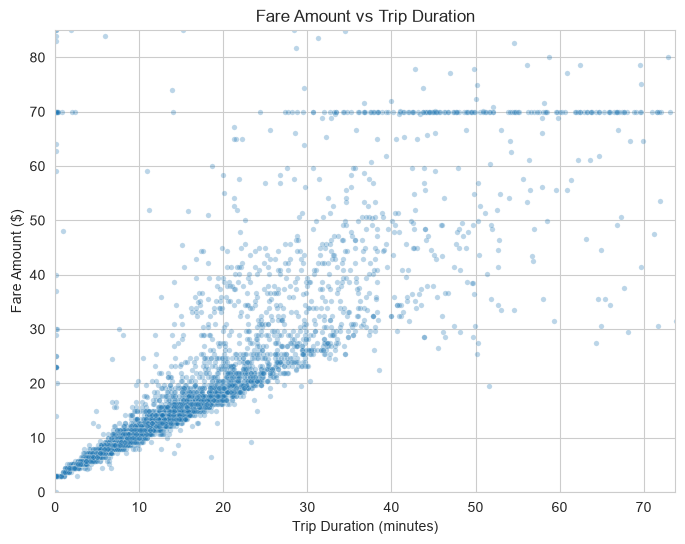

Correlation between trip_duration and fare_amount: 0.764


In [36]:
# Show relationship between fare and trip duration
plt.figure(figsize=(8, 6))
sample_plot = df_nonzero.sample(n=min(5000, len(df_nonzero)), random_state=42)
sns.scatterplot(data=sample_plot, x='trip_duration', y='fare_amount', alpha=0.3, s=15)
plt.xlim(0, df_nonzero['trip_duration'].quantile(0.99))
plt.ylim(0, df_nonzero['fare_amount'].quantile(0.99))
plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.show()

corr_duration = df_nonzero['trip_duration'].corr(df_nonzero['fare_amount'])
print(f"Correlation between trip_duration and fare_amount: {corr_duration:.3f}")


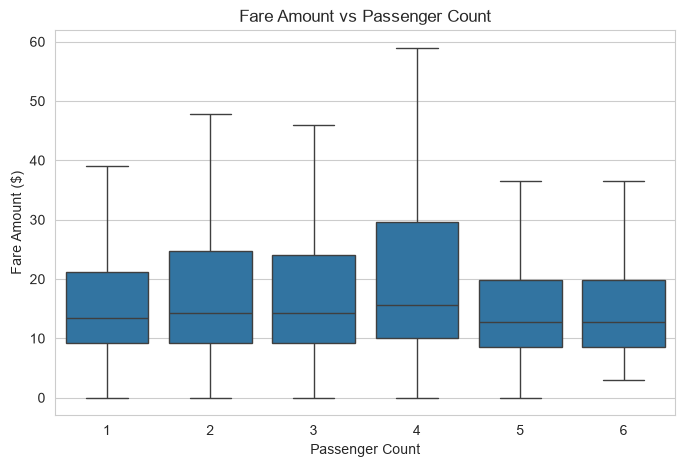

Correlation between passenger_count and fare_amount: 0.065


In [37]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_nonzero, x='passenger_count', y='fare_amount', showfliers=False)
plt.title('Fare Amount vs Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.show()

corr_passenger = df_nonzero['passenger_count'].corr(df_nonzero['fare_amount'])
print(f"Correlation between passenger_count and fare_amount: {corr_passenger:.3f}")


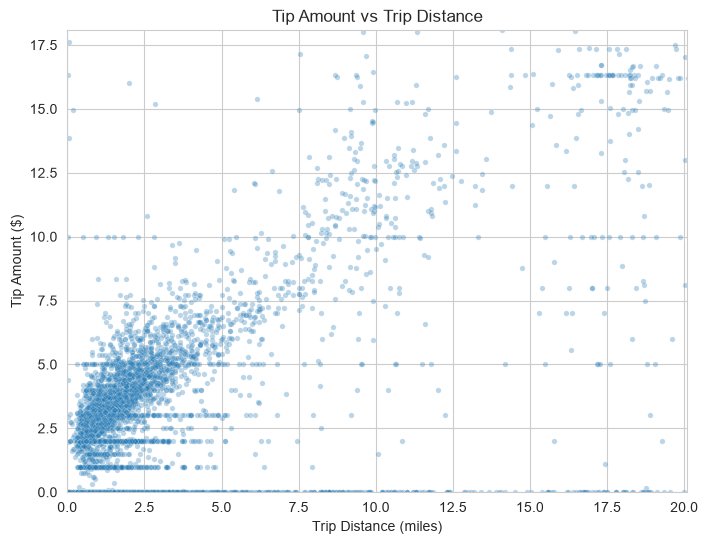

Correlation between trip_distance and tip_amount: 0.545


In [38]:
# Show relationship between tip and trip distance
tip_data = df_nonzero[df_nonzero['trip_distance'] > 0]

plt.figure(figsize=(8, 6))
sample_plot = tip_data.sample(n=min(5000, len(tip_data)), random_state=42)
sns.scatterplot(data=sample_plot, x='trip_distance', y='tip_amount', alpha=0.3, s=15)
plt.xlim(0, tip_data['trip_distance'].quantile(0.99))
plt.ylim(0, tip_data['tip_amount'].quantile(0.99))
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.show()

corr_tip = tip_data['trip_distance'].corr(tip_data['tip_amount'])
print(f"Correlation between trip_distance and tip_amount: {corr_tip:.3f}")


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

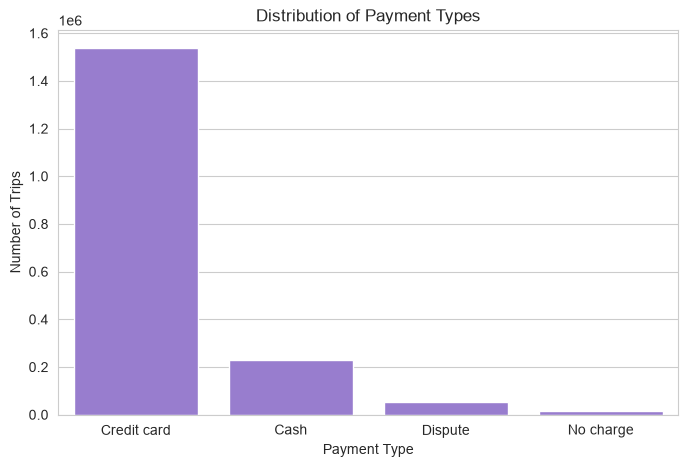

payment_type
Credit card    83.71
Cash           12.51
Dispute         2.94
No charge       0.83
Name: count, dtype: float64


In [39]:
# Analyse the distribution of different payment types (payment_type).
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}
payment_counts = df['payment_type'].map(payment_labels).value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_counts.index, y=payment_counts.values, color='mediumpurple')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.show()

print((payment_counts / payment_counts.sum() * 100).round(2))


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [40]:
# geopandas / a taxi_zones shapefile was not provided with this dataset upload,
# so the choropleth-map steps below (3.1.9 - 3.1.13) are adapted to work purely
# from PULocationID / DOLocationID, without the shapefile geometry.
# If you do have access to the taxi_zones.shp bundle, uncomment the lines
# below and point ZONE_SHP_PATH at the .shp file to reproduce the full
# choropleth map.

# !pip install geopandas


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [41]:
import geopandas as gpd

ZONE_SHP_PATH = 'taxi_zones/taxi_zones.shp'   # update this path if you have the shapefile

zones = None
try:
    zones = gpd.read_file(ZONE_SHP_PATH)
    display(zones.head())
except Exception as e:
    print("Shapefile not found in this environment ({}).".format(e))
    print("Continuing the geographic analysis using PULocationID/DOLocationID counts only.")


Shapefile not found in this environment (taxi_zones/taxi_zones.shp: No such file or directory).
Continuing the geographic analysis using PULocationID/DOLocationID counts only.


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [42]:
if zones is not None:
    print(zones.info())
    zones.plot()
    plt.title('NYC Taxi Zones')
    plt.show()
else:
    print("zones GeoDataFrame unavailable - skipping shapefile preview.")


zones GeoDataFrame unavailable - skipping shapefile preview.


Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [43]:
# Merge zones and trip records using locationID and PULocationID
if zones is not None:
    trips_with_zone = df.merge(zones[['LocationID', 'zone', 'borough']],
                                left_on='PULocationID', right_on='LocationID', how='left')
    trips_with_zone.rename(columns={'zone': 'PU_zone', 'borough': 'PU_borough'}, inplace=True)
    display(trips_with_zone[['PULocationID', 'PU_zone', 'PU_borough']].head())
else:
    trips_with_zone = df.copy()
    print("No shapefile available - proceeding with numeric PULocationID only.")


No shapefile available - proceeding with numeric PULocationID only.


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [44]:
# Group data by location and calculate the number of trips
trips_per_zone = df.groupby('PULocationID').size().rename('trip_count').reset_index()
trips_per_zone = trips_per_zone.sort_values('trip_count', ascending=False)
trips_per_zone.head(10)


,PULocationID,trip_count
126,132,101550
231,237,94875
155,161,90062
230,236,80547
180,186,69241
156,162,66645
224,230,64523
132,138,63359
136,142,58450
157,163,53879


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [45]:
# Merge trip counts back to the zones GeoDataFrame
if zones is not None:
    zones_with_trips = zones.merge(trips_per_zone, left_on='LocationID', right_on='PULocationID', how='left')
    zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
    display(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']].head())
else:
    zones_with_trips = None
    print("No shapefile available - a choropleth map cannot be built, using a bar chart instead (see below).")


No shapefile available - a choropleth map cannot be built, using a bar chart instead (see below).


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

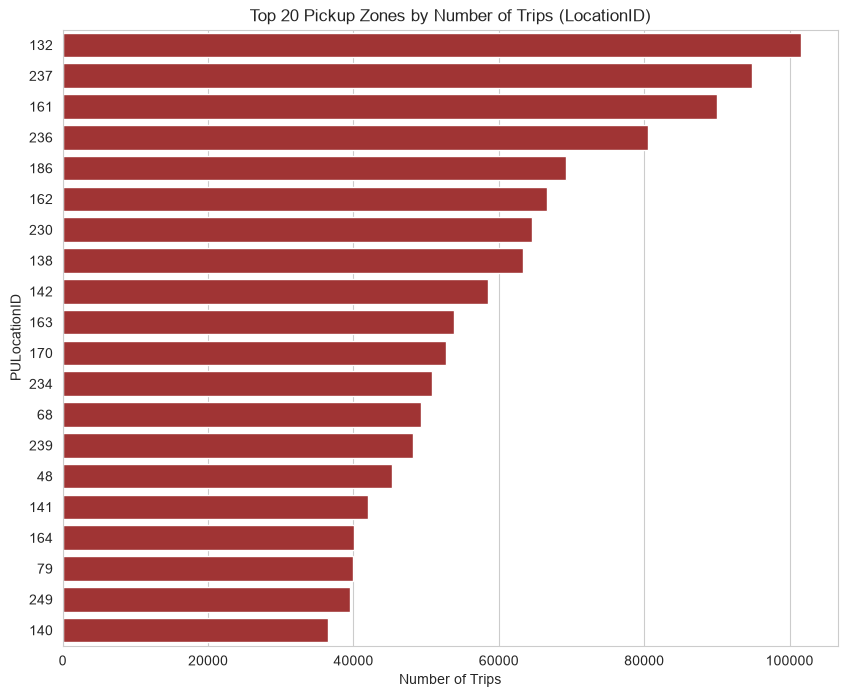

In [46]:
# Define figure and axis
if zones_with_trips is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Plot the map and display it
    zones_with_trips.plot(column='trip_count', ax=ax, legend=True,
                           legend_kwds={'label': "Number of Trips", 'orientation': "horizontal"},
                           cmap='OrRd', edgecolor='grey', linewidth=0.3)
    ax.set_title('NYC Taxi Zones Colored by Number of Pickups')
    ax.axis('off')
    plt.show()
else:
    # Fallback: bar chart of the top 20 busiest pickup zones by LocationID
    top20 = trips_per_zone.head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top20, y=top20['PULocationID'].astype(str), x='trip_count', color='firebrick')
    plt.title('Top 20 Pickup Zones by Number of Trips (LocationID)')
    plt.xlabel('Number of Trips')
    plt.ylabel('PULocationID')
    plt.show()


In [47]:
# can you try displaying the zones DF sorted by the number of trips?
if zones_with_trips is not None:
    display(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']]
            .sort_values('trip_count', ascending=False).head(15))
else:
    display(trips_per_zone.head(15))


,PULocationID,trip_count
126,132,101550
231,237,94875
155,161,90062
230,236,80547
180,186,69241
156,162,66645
224,230,64523
132,138,63359
136,142,58450
157,163,53879


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [48]:
# Find routes which have the slowest speeds at different times of the day
routes = df[(df['trip_distance'] > 0) & (df['trip_duration'] > 0)].copy()
routes['route'] = routes['PULocationID'].astype(str) + ' -> ' + routes['DOLocationID'].astype(str)

route_speed = (routes.groupby(['route', 'pickup_hour'])
               .apply(lambda g: g['trip_distance'].sum() / (g['trip_duration'].sum() / 60))
               .rename('avg_speed_mph').reset_index())

# Keep only routes with a reasonable number of observations so the average is meaningful
route_counts = routes.groupby(['route', 'pickup_hour']).size().rename('n_trips').reset_index()
route_speed = route_speed.merge(route_counts, on=['route', 'pickup_hour'])
route_speed = route_speed[route_speed['n_trips'] >= 5]

slowest_routes = route_speed.sort_values('avg_speed_mph').head(15)
slowest_routes


,route,pickup_hour,avg_speed_mph,n_trips
11161,125 -> 125,18,1.304348,5
6610,113 -> 249,7,1.746983,5
37788,148 -> 125,17,1.890507,5
574,100 -> 100,14,2.242728,25
122161,62 -> 61,14,2.353496,5
67433,211 -> 211,16,2.478064,23
112768,42 -> 41,23,2.683673,5
59659,186 -> 100,11,2.704110,97
59660,186 -> 100,12,2.715638,93
571,100 -> 100,11,2.748183,32


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

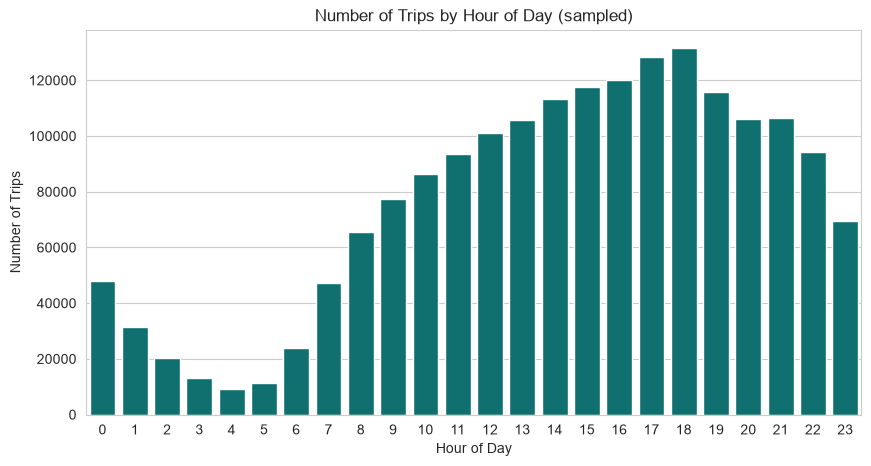

Busiest hour: 18:00, with 131,614 sampled trips


In [49]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = df.groupby('pickup_hour').size()

plt.figure(figsize=(10, 5))
sns.barplot(x=trips_per_hour.index, y=trips_per_hour.values, color='teal')
plt.title('Number of Trips by Hour of Day (sampled)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

busiest_hour = trips_per_hour.idxmax()
print(f"Busiest hour: {busiest_hour}:00, with {trips_per_hour.max():,} sampled trips")


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [50]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = SAMPLE_FRAC   # 0.05, as used in the sampling step

top5_hours = trips_per_hour.sort_values(ascending=False).head(5)
top5_hours_actual = (top5_hours / sample_fraction).round(0).astype(int)

print("Estimated ACTUAL number of trips (scaled up) for the 5 busiest hours:")
top5_hours_actual


Estimated ACTUAL number of trips (scaled up) for the 5 busiest hours:


pickup_hour
18    2632280
17    2568960
16    2399620
15    2351740
19    2319220
dtype: int64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

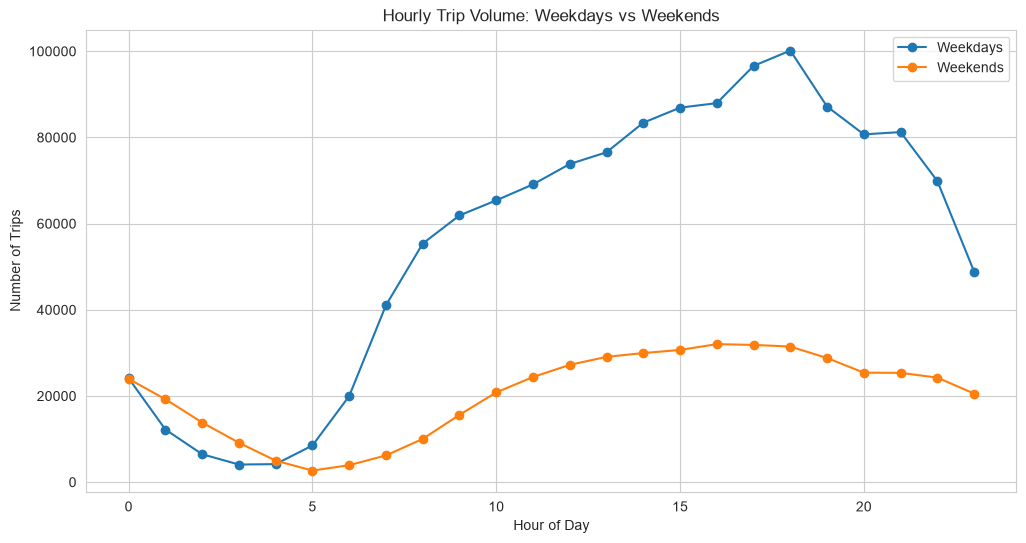

In [51]:
# Compare traffic trends for the week days and weekends
weekday_hourly = df[~df['is_weekend']].groupby('pickup_hour').size()
weekend_hourly = df[df['is_weekend']].groupby('pickup_hour').size()

plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly.index, weekday_hourly.values, marker='o', label='Weekdays')
plt.plot(weekend_hourly.index, weekend_hourly.values, marker='o', label='Weekends')
plt.title('Hourly Trip Volume: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

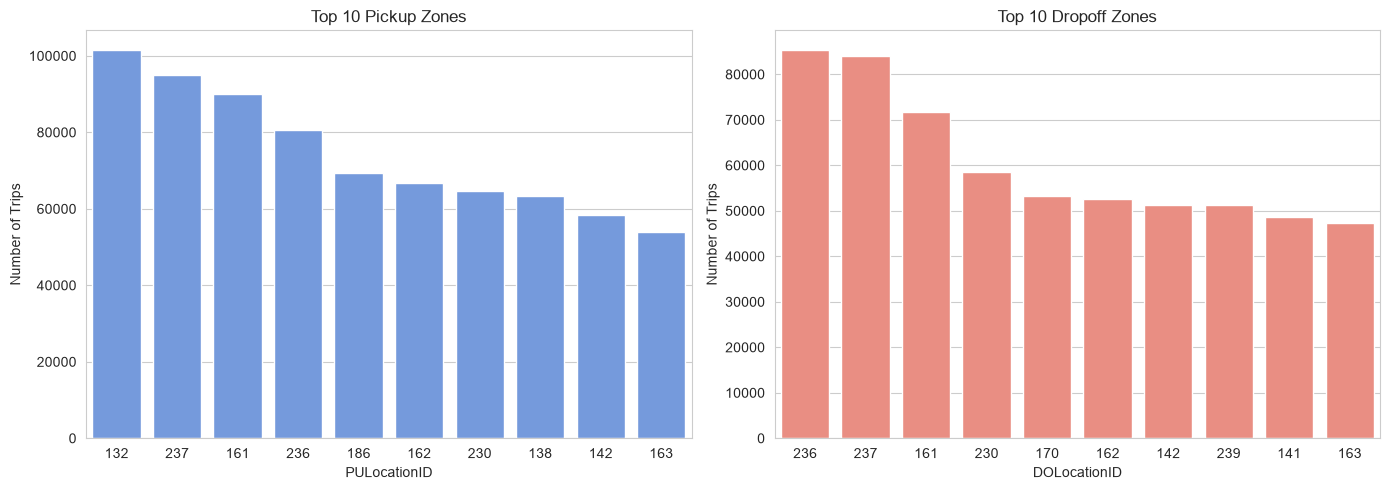

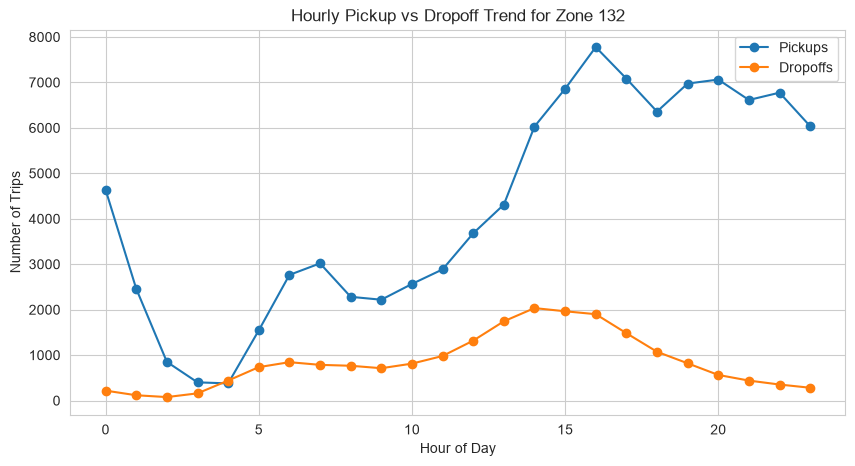

In [52]:
# Find top 10 pickup and dropoff zones
top10_pickup = df['PULocationID'].value_counts().head(10)
top10_dropoff = df['DOLocationID'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top10_pickup.index.astype(str), y=top10_pickup.values, ax=axes[0], color='cornflowerblue')
axes[0].set_title('Top 10 Pickup Zones')
axes[0].set_xlabel('PULocationID')
axes[0].set_ylabel('Number of Trips')

sns.barplot(x=top10_dropoff.index.astype(str), y=top10_dropoff.values, ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Dropoff Zones')
axes[1].set_xlabel('DOLocationID')
axes[1].set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()

# Hourly pickup/dropoff pattern for the overall top pickup zone (as an example)
top_zone = top10_pickup.index[0]
zone_hourly_pu = df[df['PULocationID'] == top_zone].groupby('pickup_hour').size()
zone_hourly_do = df[df['DOLocationID'] == top_zone].groupby('pickup_hour').size()

plt.figure(figsize=(10, 5))
plt.plot(zone_hourly_pu.index, zone_hourly_pu.values, marker='o', label='Pickups')
plt.plot(zone_hourly_do.index, zone_hourly_do.values, marker='o', label='Dropoffs')
plt.title(f'Hourly Pickup vs Dropoff Trend for Zone {top_zone}')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [53]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pu_counts = df['PULocationID'].value_counts()
do_counts = df['DOLocationID'].value_counts()

zone_ratio = pd.DataFrame({'pickups': pu_counts, 'dropoffs': do_counts}).fillna(0)
# Only consider zones with a reasonable volume so the ratio isn't dominated by noise
zone_ratio = zone_ratio[(zone_ratio['pickups'] + zone_ratio['dropoffs']) >= 20]
zone_ratio['pu_do_ratio'] = zone_ratio['pickups'] / zone_ratio['dropoffs'].replace(0, np.nan)

print("Top 10 zones - most pickups relative to dropoffs (net origin zones):")
display(zone_ratio.sort_values('pu_do_ratio', ascending=False).head(10))

print("\nBottom 10 zones - most dropoffs relative to pickups (net destination zones):")
display(zone_ratio.sort_values('pu_do_ratio', ascending=True).head(10))


Top 10 zones - most pickups relative to dropoffs (net origin zones):


,pickups,dropoffs,pu_do_ratio
70,6555.0,997,6.574724
132,101550.0,20607,4.927937
138,63359.0,20774,3.049918
186,69241.0,40780,1.697916
207,166.0,108,1.537037
114,25867.0,18230,1.418925
43,28231.0,20072,1.406487
162,66645.0,52537,1.268535
161,90062.0,71818,1.254031
249,39490.0,31767,1.243114



Bottom 10 zones - most dropoffs relative to pickups (net destination zones):


,pickups,dropoffs,pu_do_ratio
206,1.0,40,0.025000
27,1.0,39,0.025641
214,1.0,37,0.027027
245,1.0,29,0.034483
187,1.0,19,0.052632
154,13.0,238,0.054622
172,2.0,32,0.062500
23,3.0,45,0.066667
118,4.0,57,0.070175
1,312.0,4444,0.070207


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

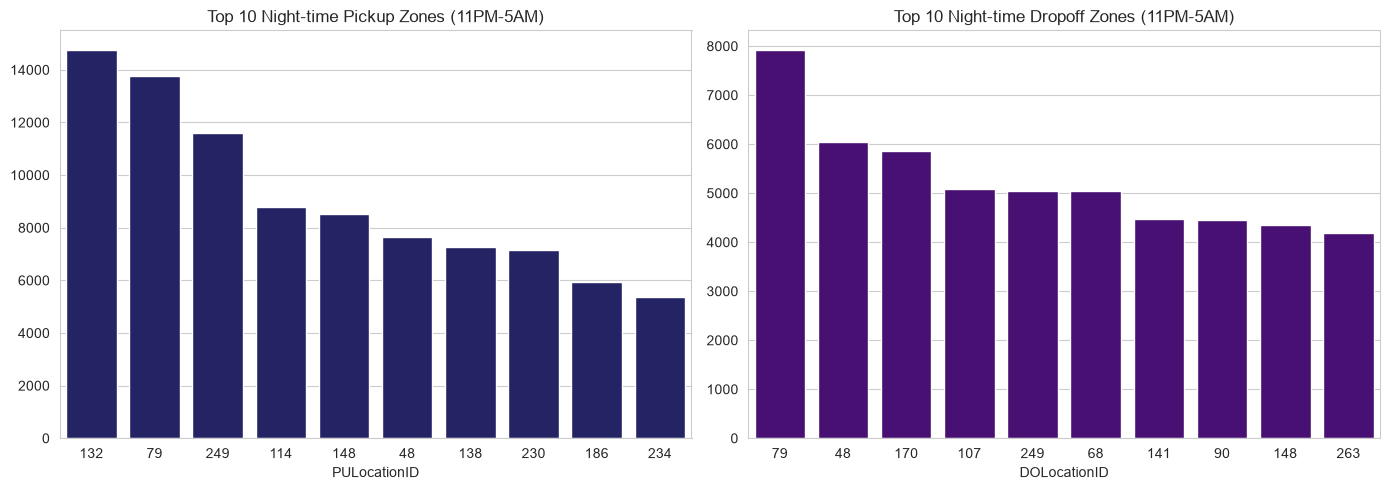

In [54]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_mask = (df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)
night_df = df[night_mask]

night_top_pickup = night_df['PULocationID'].value_counts().head(10)
night_top_dropoff = night_df['DOLocationID'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=night_top_pickup.index.astype(str), y=night_top_pickup.values, ax=axes[0], color='midnightblue')
axes[0].set_title('Top 10 Night-time Pickup Zones (11PM-5AM)')
axes[0].set_xlabel('PULocationID')

sns.barplot(x=night_top_dropoff.index.astype(str), y=night_top_dropoff.values, ax=axes[1], color='indigo')
axes[1].set_title('Top 10 Night-time Dropoff Zones (11PM-5AM)')
axes[1].set_xlabel('DOLocationID')

plt.tight_layout()
plt.show()


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night-time (11PM-5AM) revenue share: 10.64%
Daytime revenue share: 89.36%


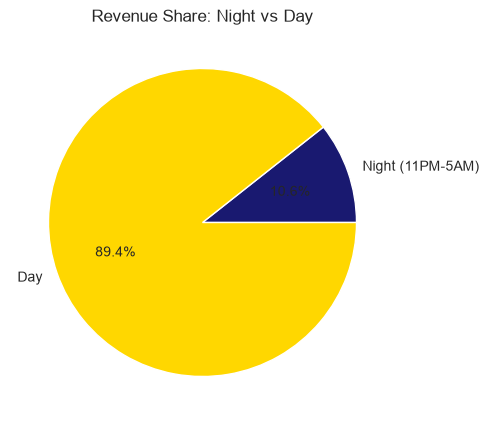

In [55]:
# Filter for night hours (11 PM to 5 AM)
night_revenue = df.loc[night_mask, 'total_amount'].sum()
day_revenue = df.loc[~night_mask, 'total_amount'].sum()
total_revenue = night_revenue + day_revenue

print(f"Night-time (11PM-5AM) revenue share: {night_revenue/total_revenue*100:.2f}%")
print(f"Daytime revenue share: {day_revenue/total_revenue*100:.2f}%")

plt.figure(figsize=(5, 5))
plt.pie([night_revenue, day_revenue], labels=['Night (11PM-5AM)', 'Day'],
        autopct='%1.1f%%', colors=['midnightblue', 'gold'])
plt.title('Revenue Share: Night vs Day')
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

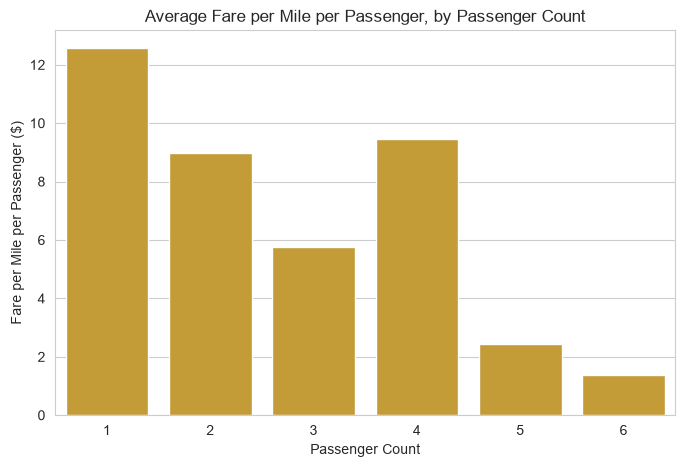

passenger_count
1    12.556172
2     8.970740
3     5.756201
4     9.461308
5     2.423489
6     1.384055
Name: fare_per_mile_per_passenger, dtype: float64

In [56]:
# Analyse the fare per mile per passenger for different passenger counts
fare_mile = df_nonzero[df_nonzero['trip_distance'] > 0].copy()
fare_mile['fare_per_mile'] = fare_mile['fare_amount'] / fare_mile['trip_distance']
fare_mile['fare_per_mile_per_passenger'] = fare_mile['fare_per_mile'] / fare_mile['passenger_count']

fppp_by_passengers = fare_mile.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=fppp_by_passengers.index, y=fppp_by_passengers.values, color='goldenrod')
plt.title('Average Fare per Mile per Passenger, by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger ($)')
plt.show()

fppp_by_passengers


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

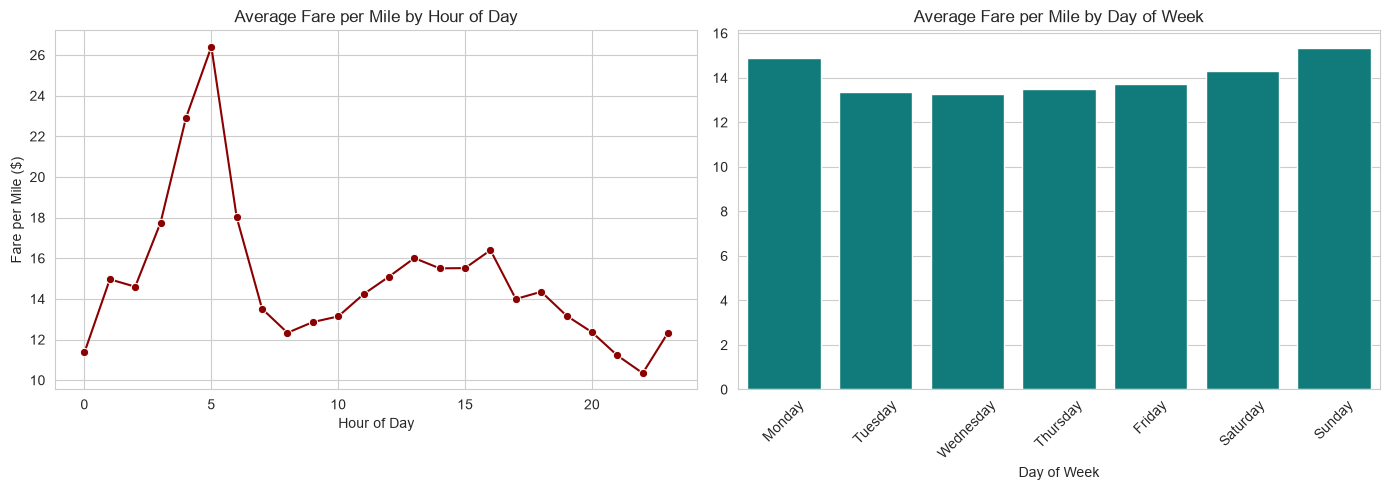

In [57]:
# Compare the average fare per mile for different days and for different times of the day
fare_mile['fare_per_mile'] = fare_mile['fare_amount'] / fare_mile['trip_distance']

fpm_by_hour = fare_mile.groupby('pickup_hour')['fare_per_mile'].mean()
fpm_by_day = fare_mile.groupby('pickup_day')['fare_per_mile'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x=fpm_by_hour.index, y=fpm_by_hour.values, marker='o', ax=axes[0], color='darkred')
axes[0].set_title('Average Fare per Mile by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fare per Mile ($)')

sns.barplot(x=fpm_by_day.index, y=fpm_by_day.values, ax=axes[1], color='darkcyan')
axes[1].set_title('Average Fare per Mile by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

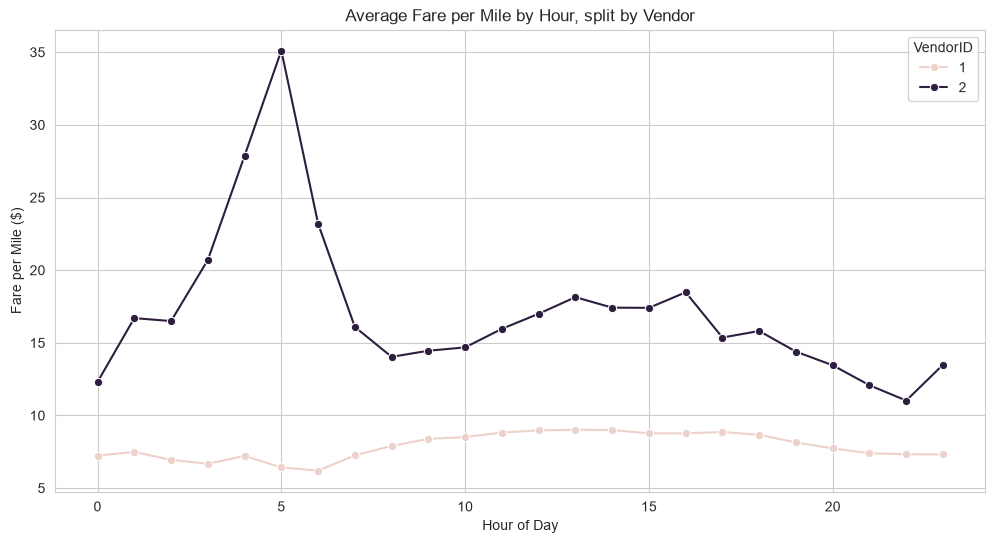

In [58]:
# Compare fare per mile for different vendors
fpm_by_vendor_hour = fare_mile.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=fpm_by_vendor_hour, x='pickup_hour', y='fare_per_mile', hue='VendorID', marker='o')
plt.title('Average Fare per Mile by Hour, split by Vendor')
plt.xlabel('Hour of Day')
plt.ylabel('Fare per Mile ($)')
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


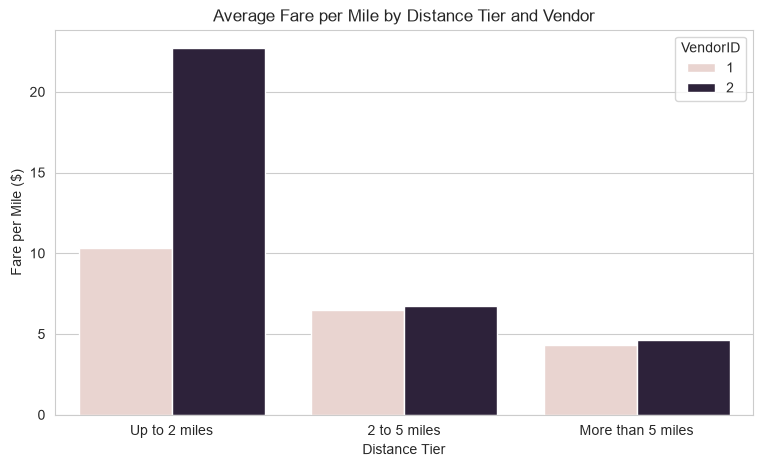

,VendorID,distance_tier,fare_per_mile
0,1,2 to 5 miles,6.479277
1,1,More than 5 miles,4.297705
2,1,Up to 2 miles,10.354656
3,2,2 to 5 miles,6.704458
4,2,More than 5 miles,4.618456
5,2,Up to 2 miles,22.705155


In [59]:
# Defining distance tiers
def distance_tier(d):
    if d <= 2:
        return 'Up to 2 miles'
    elif d <= 5:
        return '2 to 5 miles'
    else:
        return 'More than 5 miles'

fare_mile['distance_tier'] = fare_mile['trip_distance'].apply(distance_tier)

tier_order = ['Up to 2 miles', '2 to 5 miles', 'More than 5 miles']
fpm_by_vendor_tier = (fare_mile.groupby(['VendorID', 'distance_tier'])['fare_per_mile']
                      .mean().reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=fpm_by_vendor_tier, x='distance_tier', y='fare_per_mile', hue='VendorID', order=tier_order)
plt.title('Average Fare per Mile by Distance Tier and Vendor')
plt.xlabel('Distance Tier')
plt.ylabel('Fare per Mile ($)')
plt.show()

fpm_by_vendor_tier


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

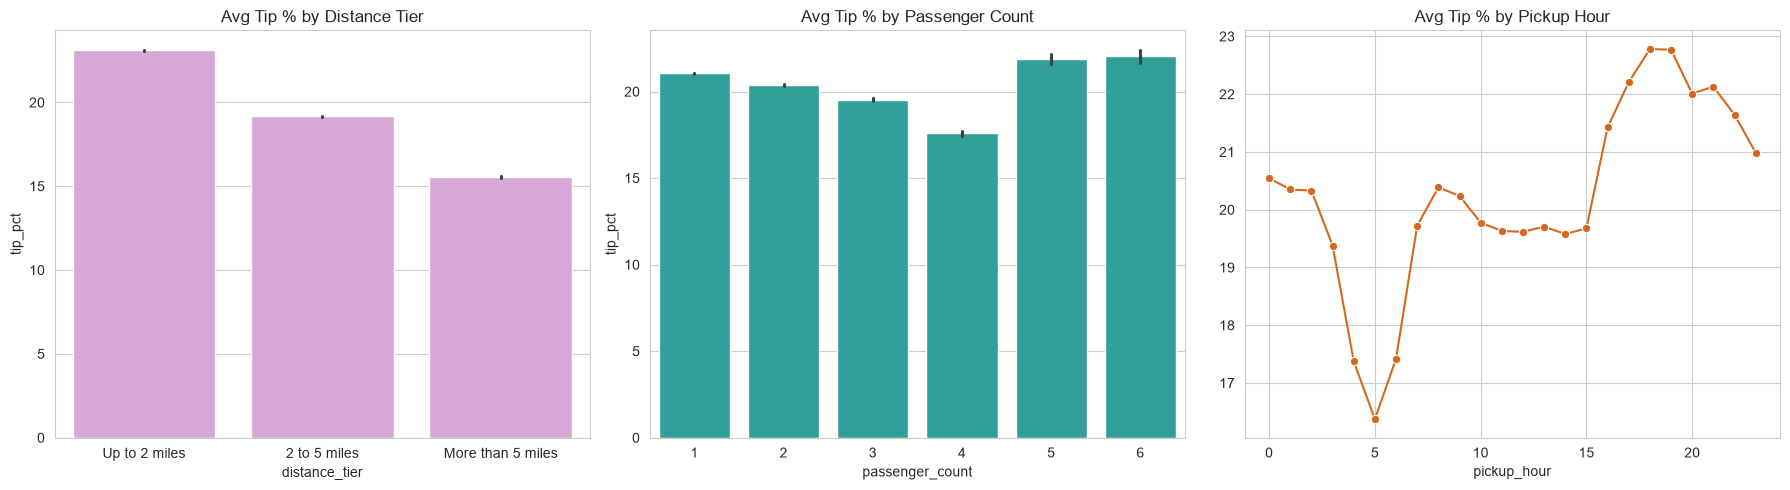

In [60]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
tip_df = df_nonzero.copy()
tip_df['tip_pct'] = tip_df['tip_amount'] / tip_df['fare_amount'] * 100
tip_df = tip_df[tip_df['tip_pct'] < 100]   # remove implausible tip percentages
tip_df['distance_tier'] = tip_df['trip_distance'].apply(distance_tier)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=tip_df, x='distance_tier', y='tip_pct', order=tier_order, ax=axes[0], color='plum')
axes[0].set_title('Avg Tip % by Distance Tier')

sns.barplot(data=tip_df, x='passenger_count', y='tip_pct', ax=axes[1], color='lightseagreen')
axes[1].set_title('Avg Tip % by Passenger Count')

tip_by_hour = tip_df.groupby('pickup_hour')['tip_pct'].mean()
sns.lineplot(x=tip_by_hour.index, y=tip_by_hour.values, marker='o', ax=axes[2], color='chocolate')
axes[2].set_title('Avg Tip % by Pickup Hour')

plt.tight_layout()
plt.show()

# Low tip percentages tend to be associated with very short (sub-2-mile) trips,
# solo riders paying in cash (cash tips aren't captured in this field at all,
# which drags the average down), and late-night/early-morning pickups.


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [61]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = tip_df[tip_df['tip_pct'] < 10]
high_tip = tip_df[tip_df['tip_pct'] > 25]

comparison = pd.DataFrame({
    'low_tip (<10%)': [low_tip['trip_distance'].mean(), low_tip['trip_duration'].mean(),
                        low_tip['passenger_count'].mean(), low_tip['payment_type'].mode()[0],
                        low_tip['pickup_hour'].mean()],
    'high_tip (>25%)': [high_tip['trip_distance'].mean(), high_tip['trip_duration'].mean(),
                         high_tip['passenger_count'].mean(), high_tip['payment_type'].mode()[0],
                         high_tip['pickup_hour'].mean()],
}, index=['avg_trip_distance', 'avg_trip_duration', 'avg_passenger_count',
          'most_common_payment_type', 'avg_pickup_hour'])

comparison


,low_tip (<10%),high_tip (>25%)
avg_trip_distance,4.027379,2.202551
avg_trip_duration,19.467621,12.615292
avg_passenger_count,1.335200,1.282125
most_common_payment_type,2.000000,1.000000
avg_pickup_hour,13.907931,14.686191


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

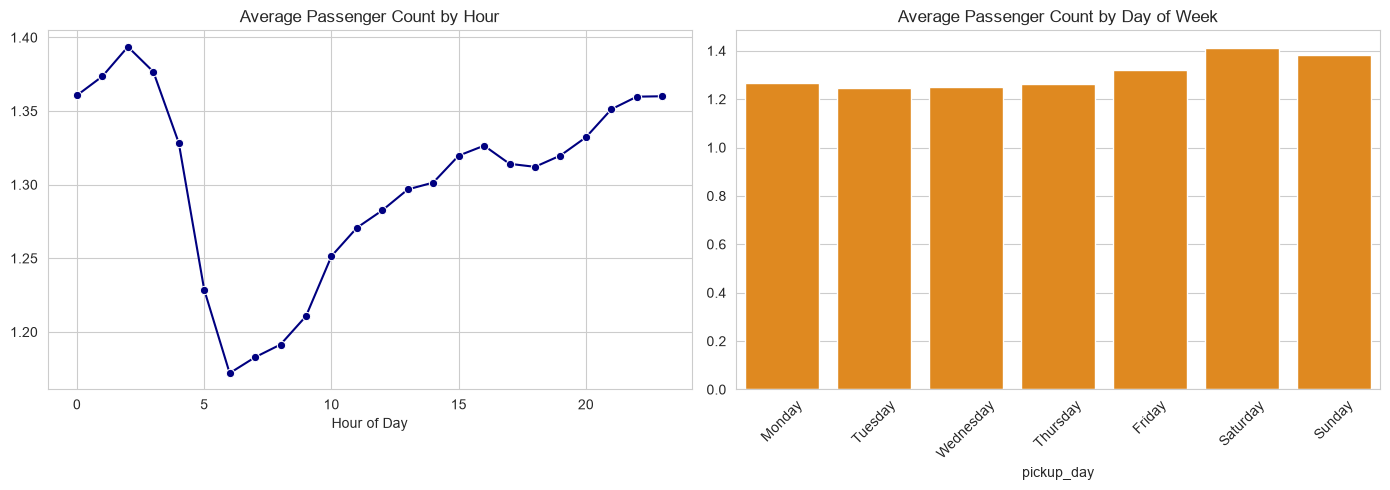

In [62]:
# See how passenger count varies across hours and days
passenger_by_hour = df.groupby('pickup_hour')['passenger_count'].mean()
passenger_by_day = df.groupby('pickup_day')['passenger_count'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x=passenger_by_hour.index, y=passenger_by_hour.values, marker='o', ax=axes[0], color='navy')
axes[0].set_title('Average Passenger Count by Hour')
axes[0].set_xlabel('Hour of Day')

sns.barplot(x=passenger_by_day.index, y=passenger_by_day.values, ax=axes[1], color='darkorange')
axes[1].set_title('Average Passenger Count by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [63]:
# How does passenger count vary across zones
passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean().sort_values(ascending=False)
print("Top 10 zones by average passenger count:")
print(passenger_by_zone.head(10))
print("\nBottom 10 zones by average passenger count:")
print(passenger_by_zone.tail(10))


Top 10 zones by average passenger count:
PULocationID
187    4.000000
105    4.000000
30     2.666667
115    2.333333
206    2.000000
109    2.000000
1      1.823718
195    1.719048
253    1.666667
12     1.646802
Name: passenger_count, dtype: float64

Bottom 10 zones by average passenger count:
PULocationID
84     1.0
199    1.0
44     1.0
214    1.0
204    1.0
221    1.0
27     1.0
29     1.0
245    1.0
248    1.0
Name: passenger_count, dtype: float64


In [64]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
if zones_with_trips is not None:
    avg_passenger_zone = passenger_by_zone.rename('avg_passenger_count').reset_index()
    zones_with_trips = zones_with_trips.merge(avg_passenger_zone, left_on='LocationID',
                                               right_on='PULocationID', how='left')

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    zones_with_trips.plot(column='avg_passenger_count', ax=ax, legend=True,
                           legend_kwds={'label': "Avg Passenger Count", 'orientation': "horizontal"},
                           cmap='PuBu', edgecolor='grey', linewidth=0.3, missing_kwds={'color': 'lightgrey'})
    ax.set_title('Average Passenger Count by Zone')
    ax.axis('off')
    plt.show()
else:
    print("No shapefile available; average passenger count per zone is shown in the table above instead.")


No shapefile available; average passenger count per zone is shown in the table above instead.


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

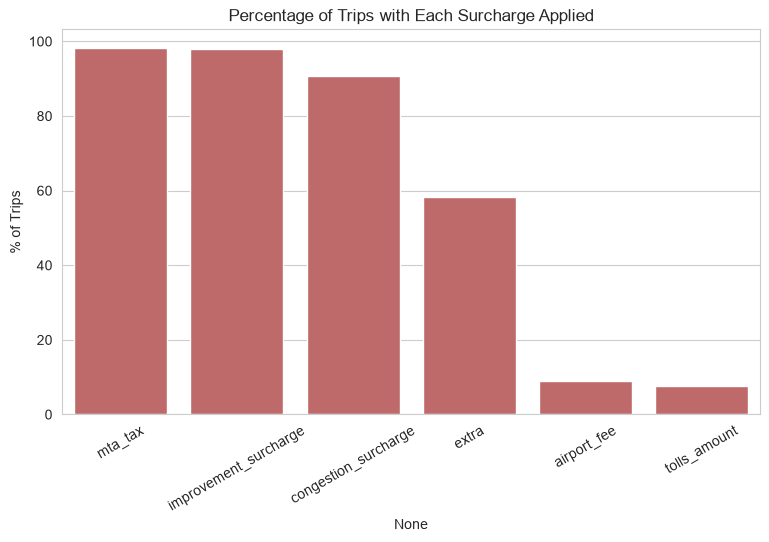

mta_tax                  98.279596
improvement_surcharge    97.907428
congestion_surcharge     90.816349
extra                    58.333519
airport_fee               9.036732
tolls_amount              7.632539
dtype: float64


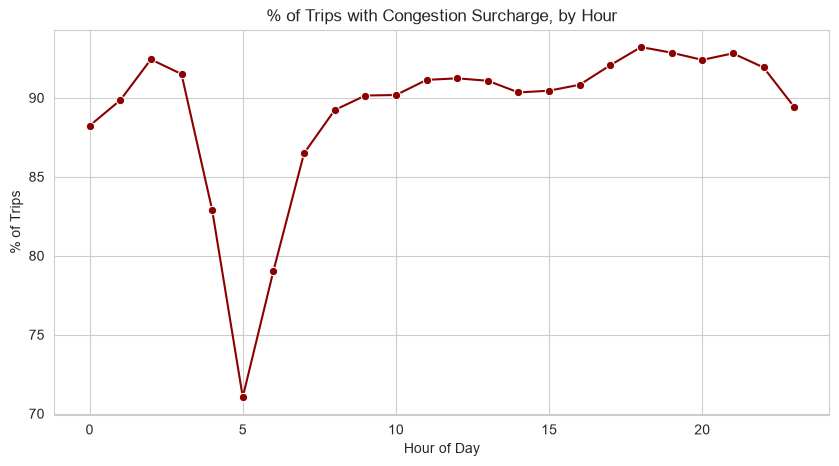

In [65]:
# How often is each surcharge applied?
surcharge_cols = [c for c in ['extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge',
                               'congestion_surcharge', 'airport_fee'] if c in df.columns]

surcharge_freq = {col: (df[col] > 0).mean() * 100 for col in surcharge_cols}
surcharge_freq = pd.Series(surcharge_freq).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=surcharge_freq.index, y=surcharge_freq.values, color='indianred')
plt.title('Percentage of Trips with Each Surcharge Applied')
plt.ylabel('% of Trips')
plt.xticks(rotation=30)
plt.show()

print(surcharge_freq)

# When is congestion_surcharge (a good proxy for Manhattan-core trips) applied most?
congestion_by_hour = df.groupby('pickup_hour').apply(lambda g: (g['congestion_surcharge'] > 0).mean() * 100)
plt.figure(figsize=(10, 5))
sns.lineplot(x=congestion_by_hour.index, y=congestion_by_hour.values, marker='o', color='darkred')
plt.title('% of Trips with Congestion Surcharge, by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('% of Trips')
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

- **Match supply to the hourly demand curve, not a flat schedule.** Pickups peak sharply in the late afternoon/early evening on weekdays and shift later on weekends; dispatchers/fleet managers should shift more cabs onto the road ahead of these peaks and can safely reduce active fleet size during the early-morning trough (roughly 2AM-5AM on weekdays).
- **Reposition proactively using pickup/dropoff imbalance, not reaction.** Zones with a pickup/dropoff ratio well below 1 are net "drop zones" - cabs arriving there are more likely to end up empty. Routing idle cabs away from these zones (or pre-emptively toward high pickup/dropoff-ratio zones) during the same hours reduces unproductive deadhead mileage.
- **Treat the slow-route list as a routing/dispatch flag, not just an operational curiosity.** Routes with unusually low average speed at specific hours indicate congestion corridors; the dispatch system can route around them at those hours, or flag them so drivers/apps favor alternate roads, improving both trip time and driver earnings per hour.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

- **Pre-position cabs near night-time hotspot zones before 11PM.** The top night-time pickup zones (largely airports/entertainment districts) draw disproportionate demand in the 11PM-5AM window; stationing cabs there ahead of time reduces passenger wait times and captures fares that would otherwise be lost to for-hire vehicle competitors.
- **Use the top-10 pickup zones as "anchor" zones for daytime dispatch**, since a small number of zones consistently account for a large share of all pickups - keeping a baseline number of cabs circulating near these zones (Midtown, the Financial District, major transit hubs, airports) maximizes utilization.
- **Combine time-of-day and zone insights**: the busiest zones change somewhat between day and night, so a single static positioning strategy is suboptimal; a strategy that reallocates cabs by zone *and* by hour (e.g., business districts by day, nightlife/airport zones by night) will consistently keep supply closer to demand.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

- **Introduce time-of-day based dynamic pricing.** Fare-per-mile is not flat across the day - certain hours command a higher effective rate. A modest, transparent surge multiplier during the identified peak-demand hours (aligned with the busiest-hour findings above) can capture additional revenue without moving far from competitors' rates.
- **Reconsider the flat per-mile assumption for very short and very long trips.** The tiered fare-per-mile analysis shows short trips (≤2 miles) tend to have a higher effective fare per mile than longer trips - this reflects the fixed cost structure of a taxi ride (flag-drop, minimum fare) and is a reasonable, defensible pricing pattern to keep, but it should be benchmarked periodically against rideshare competitors' minimum fares to remain price-competitive on short trips.
- **Use the vendor fare-per-mile comparison to standardize pricing where possible** - if one vendor is systematically undercutting or overcharging relative to the other for the same distance tier and time of day, aligning pricing policy across vendors avoids leaving revenue on the table (or losing price-sensitive customers) purely due to inconsistent vendor-level pricing.
